In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dados = {
    "x": [-3,-2,0,2,4,-1,-3,-2,0,2],
    "d": [-5,-3,1,5,9,1,-5,-3,1,5],
}

df = pd.DataFrame(dados)

# Dataset único
dataset = df[["x", "d"]].drop_duplicates().sort_values("x")

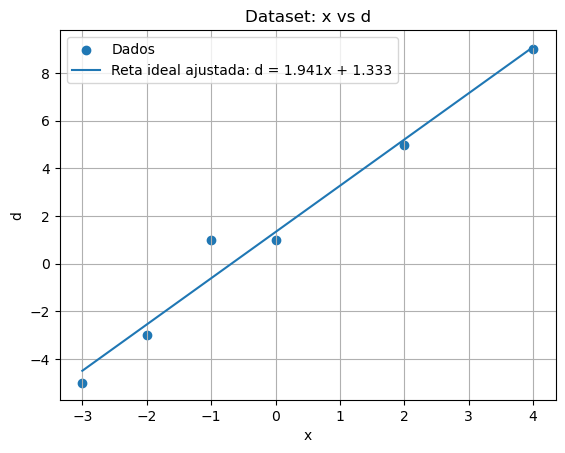

Coeficientes ideais: w=1.941176, b=1.333333


In [32]:
# 1) Pontos do dataset e reta ideal estimada dos dados (d = wx + b)
x_vals = dataset["x"].to_numpy()
d_vals = dataset["d"].to_numpy()

# Ajuste linear por minimos quadrados
w_ideal, b_ideal = np.polyfit(x_vals, d_vals, 1)

x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
d_ideal_line = w_ideal * x_line + b_ideal

plt.figure()
plt.scatter(x_vals, d_vals, label="Dados")
plt.plot(x_line, d_ideal_line, label=f"Reta ideal ajustada: d = {w_ideal:.3f}x + {b_ideal:.3f}")
plt.xlabel("x")
plt.ylabel("d")
plt.title("Dataset: x vs d")
plt.grid(True)
plt.legend()
plt.show()

print(f"Coeficientes ideais: w={w_ideal:.6f}, b={b_ideal:.6f}")

## Simulação com diferentes lr

In [33]:
len(dataset["x"])

6

In [40]:
ks = list(range(2, 10))
num_iter = 30
dataset_size = len(dataset)

# Guarda os vetores de cada variavel para cada k
resultados_por_k = {}

for k in ks:
    lr = 1 / (2**k)
    w = 0
    b = 0

    e_k = []
    w_k = []
    y_k = []
    b_k = []

    print(f"Valor de k={k}, lr={lr}")

    for i in range(num_iter):
        idx = i % dataset_size  # cicla no dataset quando i > tamanho
        x = dataset["x"].iloc[idx]
        d = dataset["d"].iloc[idx]

        y = w * x + b
        e = d - y

        w += lr * e * x
        b += lr * e

        e_k.append(e)
        w_k.append(w)
        y_k.append(y)
        b_k.append(b)

    resultados_por_k[k] = {
        "lr": lr,
        "e": e_k,
        "w": w_k,
        "y": y_k,
        "b": b_k,
    }

# Vetores por variavel, indexados pela posicao de ks
es_por_k = [resultados_por_k[k]["e"] for k in ks]
ws_por_k = [resultados_por_k[k]["w"] for k in ks]
ys_por_k = [resultados_por_k[k]["y"] for k in ks]
bs_por_k = [resultados_por_k[k]["b"] for k in ks]

print("Pronto: resultados_por_k, es_por_k, ws_por_k, ys_por_k, bs_por_k")

Valor de k=2, lr=0.25
Valor de k=3, lr=0.125
Valor de k=4, lr=0.0625
Valor de k=5, lr=0.03125
Valor de k=6, lr=0.015625
Valor de k=7, lr=0.0078125
Valor de k=8, lr=0.00390625
Valor de k=9, lr=0.001953125
Pronto: resultados_por_k, es_por_k, ws_por_k, ys_por_k, bs_por_k


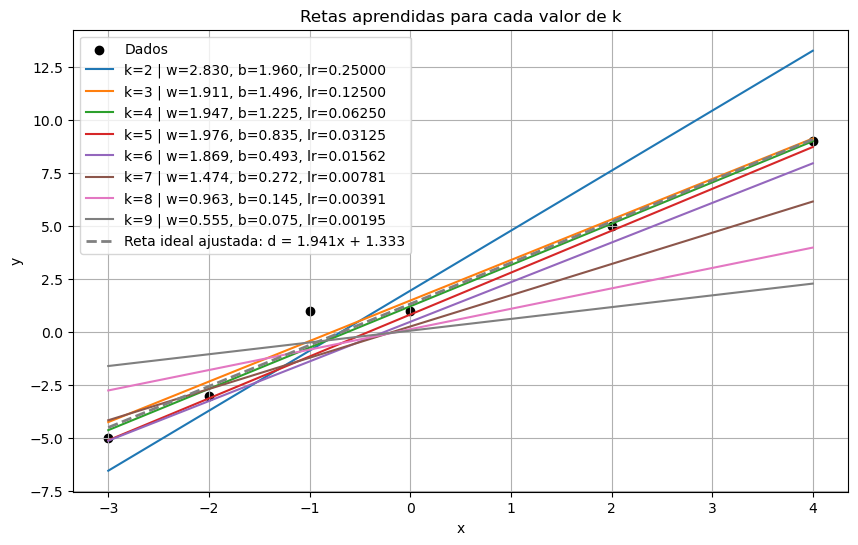

In [42]:
# Reta aprendida para cada k: y = w(k)x + b(k)
x_line = np.linspace(dataset["x"].min(), dataset["x"].max(), 200)

plt.figure(figsize=(10, 6))
plt.scatter(dataset["x"], dataset["d"], color="black", label="Dados")

for k in ks:
    w_k_final = resultados_por_k[k]["w"][-1]
    b_k_final = resultados_por_k[k]["b"][-1]
    y_line = w_k_final * x_line + b_k_final
    plt.plot(x_line, y_line, label=f"k={k} | w={w_k_final:.3f}, b={b_k_final:.3f}, lr={resultados_por_k[k]['lr']:.5f}")

# Reta ideal obtida por ajuste linear nos dados
w_ideal, b_ideal = np.polyfit(dataset["x"].to_numpy(), dataset["d"].to_numpy(), 1)
plt.plot(x_line, w_ideal * x_line + b_ideal, "--", color="gray", linewidth=2,
         label=f"Reta ideal ajustada: d = {w_ideal:.3f}x + {b_ideal:.3f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Retas aprendidas para cada valor de k")
plt.grid(True)
plt.legend()
plt.show()

## Evolução do Erro a cada iteração em função de cada k

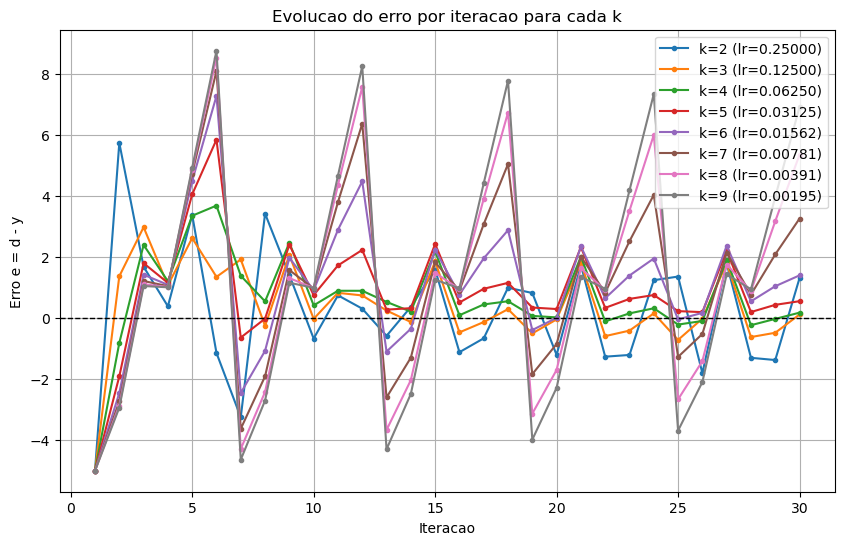

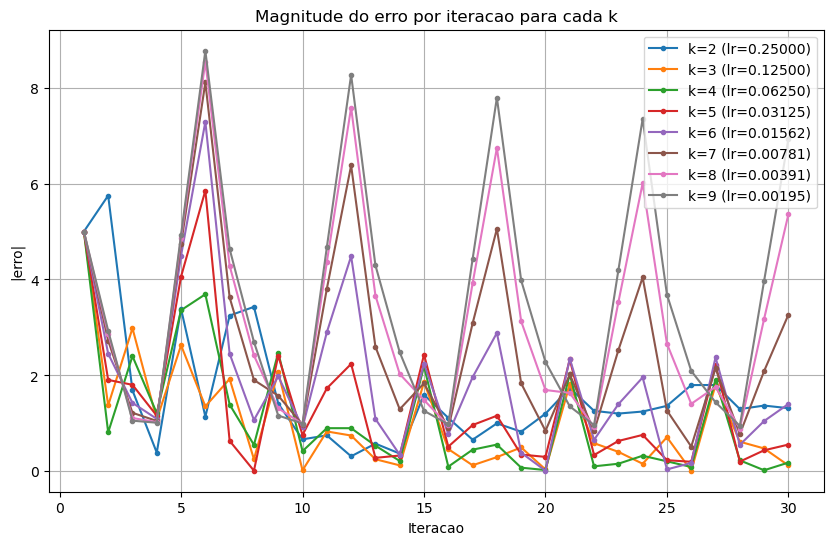

In [43]:
# Erro vs iteracao para cada k
iteracoes = np.arange(1, num_iter + 1)

plt.figure(figsize=(10, 6))
for k in ks:
    erro_k = resultados_por_k[k]["e"]
    plt.plot(iteracoes, erro_k, marker="o", markersize=3,
             label=f"k={k} (lr={resultados_por_k[k]['lr']:.5f})")

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Iteracao")
plt.ylabel("Erro e = d - y")
plt.title("Evolucao do erro por iteracao para cada k")
plt.grid(True)
plt.legend()
plt.show()

# Opcional: magnitude do erro (valor absoluto)
plt.figure(figsize=(10, 6))
for k in ks:
    erro_abs_k = np.abs(resultados_por_k[k]["e"])
    plt.plot(iteracoes, erro_abs_k, marker="o", markersize=3,
             label=f"k={k} (lr={resultados_por_k[k]['lr']:.5f})")

plt.xlabel("Iteracao")
plt.ylabel("|erro|")
plt.title("Magnitude do erro por iteracao para cada k")
plt.grid(True)
plt.legend()
plt.show()